<a href="https://colab.research.google.com/github/lee-woonju/study-hongong-mldl/blob/main/03_3_%ED%8A%B9%EC%84%B1_%EA%B3%B5%ED%95%99%EA%B3%BC_%EA%B7%9C%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KEYWORD : 다중 회귀, 특성공학, 릿지, 라쏘, 하이퍼파라미터
```
여러 특성을 사용한 다중 회귀
복잡한 모델의 과대적합을 막기 위한 릿지와 라쏘 회귀
```

---

##  다중 회귀 : 여러 개의 특성을 사용한 선형 회귀
  - 선형 회귀는 특성이 많을수록 엄청난 효과를 낸다.
## 특성 공학 : 기존의 특성을 사용해 새로운 특성을 뽑아내는 작업
  - 사이킷런에서 편리한 도구 제공 :

  

In [6]:
# 데이터 준비
# 판다스(데이터 분석 라이브러리)
## 데이터프레임(판다스의 핵심 데이터 구조)
### csv -> 판다스 데이터프레임

# 데이터 --> https://bit.ly/perch_csv_data
import pandas as pd
perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full.head()


,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [10]:
# 타깃 데이터 http://bit.ly/perch_data

import numpy as np
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

# perch_full 과 perch_weight 를 훈련 세트와 테스트 세트로 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)


# 사이킷런의 변환기
## 변환기 : 특성을 만들거나 전처리하기 위한 다양한 클래스

from sklearn.preprocessing import PolynomialFeatures

# 무게 = a x 길이 + b x 높이 + c x 두께 + d x 1
# fit() : 특성 개수를 파악
poly = PolynomialFeatures()
poly.fit([[2,3]])
print(poly.transform([[2,3]]))
# [[1. 2. 3. 4. 6. 9.]]
## 특성 제곱 항, 특성끼리 곱한 항, 그리고 1
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2,3]])
print(poly.transform([[2,3]]))
# [[2. 3. 4. 6. 9.]]
## 1이 빠짐
## 사이킷런 선형 모델은 자동으로 절편을 추가하기 때문에 굳이 필요 없음
## include_bias=False 지정하지 않아도 무시하긴 함



[[1. 2. 3. 4. 6. 9.]]
[[2. 3. 4. 6. 9.]]


In [14]:
# train_input에 적용
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input) # 훈련
train_poly = poly.transform(train_input)
print(train_poly.shape)

# 9개의 특성이 어떻게 만들어졌는지 확인
poly.get_feature_names_out()

# test_input 에 적용(테스트 세트 변환)
test_poly = poly.transform(test_input)


# (42, 9) 의미
## 데이터 56개 중에 보통 75% 정도를 훈련 세트(train)로 떼어내면 딱 42개, 14개는 테스트용
## 42개의 샘플(데이터 행)이 있고, 각 샘플마다 9개의 특성(Feature)이 만들어졌다

(42, 9)


In [17]:
# 다중 회귀 모델 훈련하기
## 선형 회귀 모델 훈련과 같다, 다만 여러 개의 특성을 사용하여 선형 회귀를 수행하는 것뿐.

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9903183436982125
0.9714559911594111


# [?] Polynomialfeatures의 fit과 LinearRegression 의 fit 차이
## Polynomialfeatures의 fit() : 데이터의 모양(형태)을 어떻게 바꿀지 결정하는 과정
### - 필요한 데이터 : 오직 입력 데이터
### - 다음 단계 : transform()으로 데이터 변환
## LinearRegression의 fit() : 변환된 데이터와 정답 사이의 상관관계를 찾는 과정
### - 필요한 데이터 : 입력과 정답 모두 필요
### - 다음 단계 : predict()로 정답 예측

In [20]:
# PolynomialFeatures의 degree 매개 변수 : 고차항의 최대 차수 지정
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape) # 특성의 개수가 55개로 늘어남


(42, 55)


In [24]:
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

print(lr.score(test_poly, test_target))

# 특성의 개수를 늘리면 선형 모델은 아주 강력해짐
## 훈련 세트에 대해 거의 완벽하게 학습할 수 있음
### 하지만! 이런 모델은 훈련 세트에 너무 과대적합되므로 테스트 세트에서는 형편없는 점수를 만듦
### 과대적합을 줄이는 또 다른 방법 ==> 규제

0.9999999999996433
-144.40579436844948


# 규제  ( regularization )
```
머신러닝 모델이 훈련 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
```

In [30]:
# StandardScaler
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
# 표준점수로 변환
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

# 선형 회귀 모델에 규제를 추가한 모델을 "릿지"와 "라쏘"라고 부름
## 릿지 : 계수를 제곱한 값을 기준으로 규제를 적용
## - 계수들을 전체적으로 '골고루 작게' 만듦
## 라쏘 : 계수의 절댓값을 기준으로 규제를 적용
## - 중요하지 않다고 생각되는 계수를 '아예 0으로' 만들어버리기도 함
### 일반적으로 릿지를 선호

In [37]:
# 릿지 회귀
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))  # 공부한 문제로 시험 보기 -> 점수가 낮다 -> 공부를 덜함 -> 과소적합
print(ridge.score(test_scaled, test_target))    # 처음 보는 문제로 시험 보기 -> 훈련점수보다 너무 낮다 -> 문제만 외우고 응용을 못한다 -> 과대적합



0.9896101671037343
0.9790693977615387


# 과소적합, 과대적합
## 과소적합 : 훈련세트 점수 < 테스트세트 점수 (둘다낮음)
### 공부한 문제로 시험 보기 -> 낮은 점수 -> 공부를 덜함
### 특성 추가, 규제 약화, 더 복잡한 모델 사용


## 과대적합 : 훈련세트 점수 >>> 테스트 점수
### 처음 보는 문제로 시험 보기 -> 훈련세트보다 너무 낮은 점수 -> 문제만 달달 외우고 응용력이 없음
### 규제(릿지, 라쏘) 강화, 특성 개수 줄이기

## [?] 얼마나 차이나야 너무 낮다고 할까?
### 결정계수(R^2)는 최대값이 1.0
  - 0.01 ~ 0.03 : 베스트
  - 0.1(10%) 이상 차이 : 이때부터는 과대적합 의심




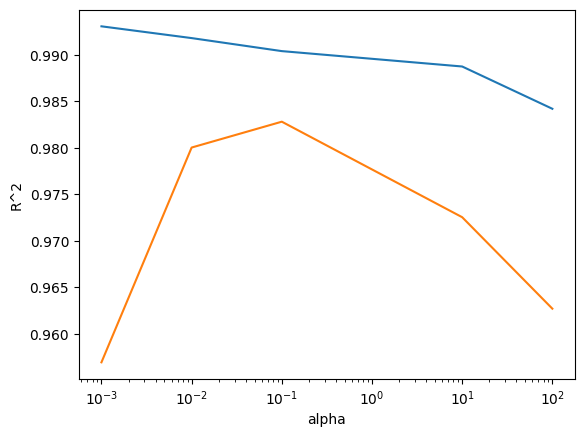

In [42]:
# 하이퍼 파라미터 alpha = 규제강도 조절
import matplotlib.pyplot as plt
train_score = []
test_score = []

# alpha 값을 0.001dptj 100까지 10배씩 늘려가며 릿지 회귀 모델 훈련한 다음
# 훈련 세트와 테스트 세트의 점수를 파이썬 리스트에 저장
alpha_list = [0.001, 0.01, 0.1, 10, 100]
for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(train_scaled, train_target)
  train_score.append(ridge.score(train_scaled, train_target))
  test_score.append(ridge.score(test_scaled, test_target))

# 그래프 그리기
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()


In [45]:
  ridge = Ridge(alpha=0.1)
  ridge.fit(train_scaled, train_target)
  print(ridge.score(train_scaled, train_target))
  print(ridge.score(test_scaled, test_target))

0.9903815817570367
0.9827976465386928


# 라쏘 회귀